# ✅ ŘEŠENÍ: Notebook 02 — Statistická analýza & EKC

> **Otevři toto řešení až po vlastním pokusu v `02_statistika_ekc_ULOHY.ipynb`!**

---

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, warnings
from scipy import stats
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

df = pd.read_csv('../output/ekc_analysis.csv')
if 'log_gdp' not in df.columns:
    df['log_gdp'] = np.log(df['mean_gdp'])
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
df['income_group'] = pd.Categorical(df['income_group'], categories=income_order, ordered=True)
print(f'Načteno {len(df)} zemí')
assert 180 <= len(df) <= 210, f"Neocekavany pocet zemi: {len(df)} (ocekavano ~199) — zkontroluj notebook 01!"

Načteno 199 zemí


## Řešení Úlohy 1 — Grafická kontrola: Scatter plot HDP vs. změna lesa


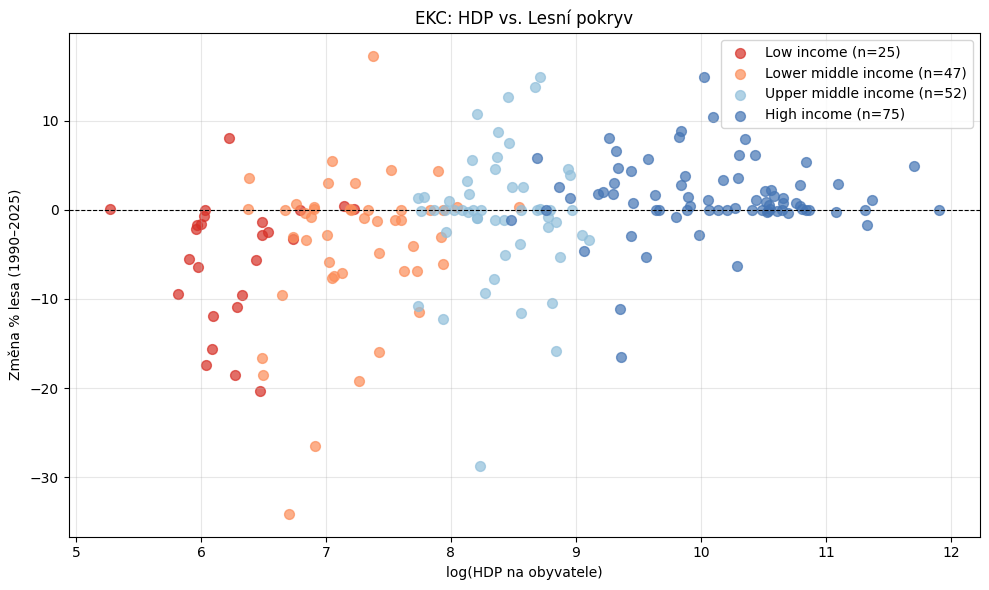

In [2]:
income_colors = {'Low income': '#d73027', 'Lower middle income': '#fc8d59',
                 'Upper middle income': '#91bfdb', 'High income': '#4575b4'}
fig, ax = plt.subplots(figsize=(10, 6))
for group, color in income_colors.items():
    mask = df['income_group'] == group
    ax.scatter(df[mask]['log_gdp'], df[mask]['forest_change'],
               label=f'{group} (n={mask.sum()})', color=color, alpha=0.7, s=50)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('log(HDP na obyvatele)')
ax.set_ylabel('Změna % lesa (1990–2025)')
ax.set_title('EKC: HDP vs. Lesní pokryv')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Řešení Úlohy 2: Pearsonova korelace


In [3]:
cor_data = df[['log_gdp', 'forest_change']].dropna()
r, p_value = stats.pearsonr(cor_data['log_gdp'], cor_data['forest_change'])
print(f'Korelační koeficient r: {r:.4f}')
print(f'p-hodnota:              {p_value:.4f}')
print(f'Statisticky významná:   {"ANO" if p_value < 0.05 else "NE"} (p < 0.05)')

Korelační koeficient r: 0.3625
p-hodnota:              0.0000
Statisticky významná:   ANO (p < 0.05)


## Řešení Úlohy 3: Polynomiální regrese (EKC křivka)


In [4]:
reg_data = df[['log_gdp', 'forest_change']].dropna()
x = reg_data['log_gdp'].values
y = reg_data['forest_change'].values

coeffs_quad = np.polyfit(x, y, 2)
a, b, c = coeffs_quad

x_vertex = -b / (2 * a)
gdp_inflection = np.exp(x_vertex)

y_pred = np.polyval(coeffs_quad, x)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot

print(f'Koeficienty: a={a:.5f}, b={b:.5f}, c={c:.5f}')
print(f'Bod zlomu:   ${gdp_inflection:,.0f}/os.')
print(f'R²:          {r_squared:.4f}')

Koeficienty: a=-0.36252, b=7.91240, c=-41.49626
Bod zlomu:   $54,885/os.
R²:          0.1456


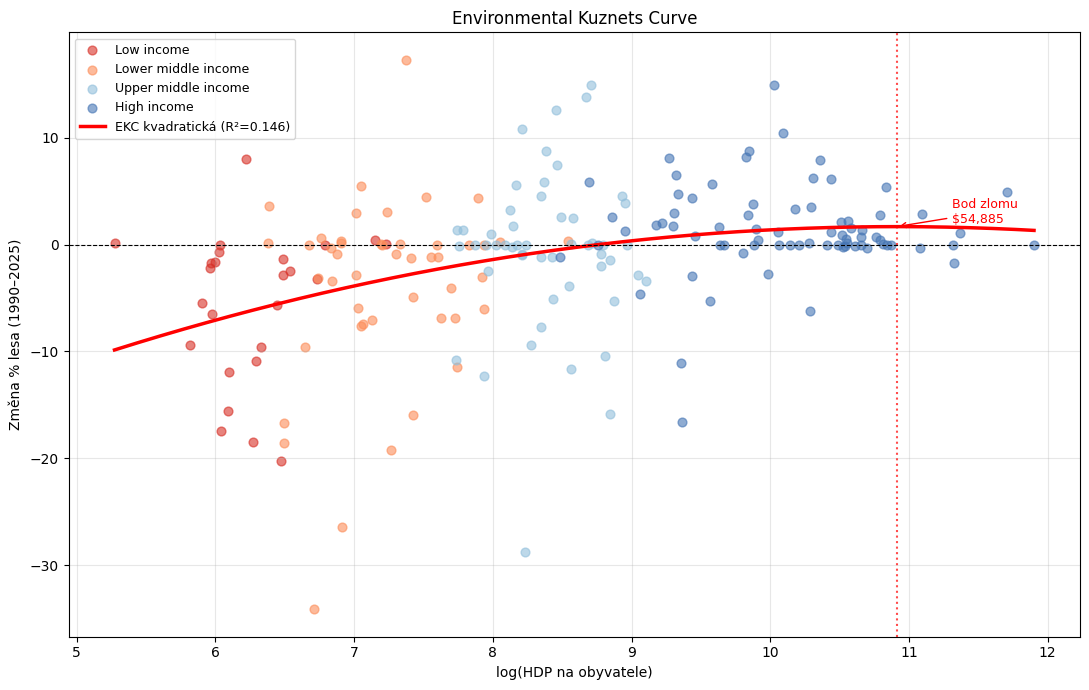

In [5]:
# Scatter plot s EKC křivkou
fig, ax = plt.subplots(figsize=(11, 7))
for group, color in income_colors.items():
    mask = df['income_group'] == group
    ax.scatter(df[mask]['log_gdp'], df[mask]['forest_change'], color=color, alpha=0.6, s=40, label=group)

x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, np.polyval(coeffs_quad, x_line), 'r-', linewidth=2.5,
        label=f'EKC kvadratická (R²={r_squared:.3f})')
ax.axvline(x_vertex, color='red', linestyle=':', alpha=0.7)
ax.annotate(f'Bod zlomu\n${gdp_inflection:,.0f}',
            xy=(x_vertex, np.polyval(coeffs_quad, x_vertex)),
            xytext=(x_vertex + 0.4, 2), arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('log(HDP na obyvatele)')
ax.set_ylabel('Změna % lesa (1990–2025)')
ax.set_title('Environmental Kuznets Curve')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Řešení Úlohy 4: Test hypotézy Q1


In [6]:
high_income_change = df[df['income_group'] == 'High income']['forest_change'].dropna()
low_income_change  = df[df['income_group'] == 'Low income']['forest_change'].dropna()

u_stat, p_mw = stats.mannwhitneyu(high_income_change, low_income_change, alternative='greater')
print(f'Mann-Whitney U = {u_stat:.0f}, p = {p_mw:.4f}')
print(f'Závěr: H1 {"POTVRZENA" if p_mw < 0.05 else "ZAMÍTNUTA"}')

t_stat, p_ttest = stats.ttest_1samp(high_income_change, 0, alternative='greater')
print(f'\nt-test (High income > 0): t={t_stat:.4f}, p={p_ttest:.4f}')
print(f'Závěr: {"High income PRŮMĚRNĚ ZALESŇUJÍ" if p_ttest < 0.05 else "Nelze potvrdit"}')

Mann-Whitney U = 1594, p = 0.0000
Závěr: H1 POTVRZENA

t-test (High income > 0): t=2.7944, p=0.0033
Závěr: High income PRŮMĚRNĚ ZALESŇUJÍ


## Řešení Úlohy 5: Regionální analýza (Q2)


In [7]:
regional_summary = (
    df.groupby('region')['forest_change']
    .agg(n='count', mean_change='mean', median_change='median', std_change='std')
    .sort_values('mean_change')
    .round(3)
)
print(regional_summary)

region_groups = [df[df['region'] == r]['forest_change'].dropna().values
                 for r in df['region'].dropna().unique()]
region_groups = [g for g in region_groups if len(g) > 0]
h_stat, p_kw = stats.kruskal(*region_groups)
print(f'\nKruskal-Wallis: H={h_stat:.4f}, p={p_kw:.6f}')
print(f'Regionální rozdíly jsou {"STATISTICKY VÝZNAMNÉ" if p_kw < 0.05 else "NEVÝZNAMNÉ"}')

                             n  mean_change  median_change  std_change
region                                                                
Sub-Saharan Africa          46       -5.775         -3.155       7.796
Latin America & Caribbean   35       -3.204         -1.970       8.555
East Asia & Pacific         33       -1.099         -0.120       8.214
Middle East & North Africa  19        0.276          0.000       0.869
North America                3        0.543          0.710       0.482
South Asia                   8        0.717          0.000       2.783
Europe & Central Asia       55        2.747          1.670       3.353

Kruskal-Wallis: H=62.5337, p=0.000000
Regionální rozdíly jsou STATISTICKY VÝZNAMNÉ


## Řešení Úlohy 6: Outliers — Paradoxní země (Q3)


In [8]:
q75_gdp = df['mean_gdp'].quantile(0.75)
q25_gdp = df['mean_gdp'].quantile(0.25)

rich_deforesters = df[(df['mean_gdp'] > q75_gdp) & (df['forest_change'] < 0)]
poor_reforesters = df[(df['mean_gdp'] < q25_gdp) & (df['forest_change'] > 0.5)]

print(f'Bohaté odlesňovatelé ({len(rich_deforesters)}):')
print(rich_deforesters[['country', 'income_group', 'region', 'mean_gdp', 'forest_change']]
      .sort_values('forest_change').to_string(index=False))
print(f'\nChudé zalesňovatelé ({len(poor_reforesters)}):')
print(poor_reforesters[['country', 'income_group', 'region', 'mean_gdp', 'forest_change']]
      .sort_values('forest_change', ascending=False).to_string(index=False))

def classify_outlier(row):
    if row['mean_gdp'] > q75_gdp and row['forest_change'] < 0: return 'rich_deforester'
    elif row['mean_gdp'] < q25_gdp and row['forest_change'] > 0.5: return 'poor_reforester'
    elif row['forest_change'] >= 0: return 'expected_positive'
    else: return 'expected_negative'

df['outlier_category'] = df.apply(classify_outlier, axis=1)

Bohaté odlesňovatelé (8):
       country income_group                    region  mean_gdp  forest_change
        Brunei  High income       East Asia & Pacific 29356.312         -6.260
   South Korea  High income       East Asia & Pacific 21725.381         -2.780
Cayman Islands  High income Latin America & Caribbean 82972.181         -1.710
        Sweden  High income     Europe & Central Asia 44188.044         -0.310
        Norway  High income     Europe & Central Asia 65035.737         -0.300
       Belgium  High income     Europe & Central Asia 37312.708         -0.220
     Australia  High income       East Asia & Pacific 40512.673         -0.140
         Japan  High income       East Asia & Pacific 37670.552         -0.120

Chudé zalesňovatelé (6):
   country        income_group                region  mean_gdp  forest_change
    Rwanda          Low income    Sub-Saharan Africa   504.067          8.010
     Ghana Lower middle income    Sub-Saharan Africa  1151.398          5.490
   

## Řešení Úlohy 7: Forest Policy — Vysvětlují data o politice paradoxní země?


---
### Forest Policy: Vysvětluje politika paradoxní země?

Data z FAO obsahují pro každou zemi informaci, zda má:
- **Národní politiku** pro udržitelnou správu lesů (SFM)
- **Národní legislativu** pro udržitelnou správu lesů
- **Platformu pro zapojení stakeholderů**

**Hypotéza**: Chudé zalesňovatelé mají silnější lesní politiku než chudé odlesňovatelé.

In [9]:
# Načtení Forest Policy datasetu
fp_raw = pd.read_csv('../../data_raw/Forest_Policy_Legislation.csv', on_bad_lines='skip')

# Vybereme jen relevantní sloupce a přejmenujeme je
fp = fp_raw[['iso3', 'National policies supporting SFM',
             'National legislations supporting SFM',
             'National platform for stakeholder participation']].copy()
fp.columns = ['code', 'has_policy', 'has_legislation', 'has_platform']

# Převod yes/no na True/False
for col in ['has_policy', 'has_legislation', 'has_platform']:
    fp[col] = fp[col].str.strip().str.lower().map({'yes': True, 'no': False})

# Policy score: součet počtu zavedených opatření (0–3)
fp['policy_score'] = fp[['has_policy', 'has_legislation', 'has_platform']].sum(axis=1)

print(f'Forest Policy data: {len(fp)} zemí')
print(f'Průměrný policy score: {fp["policy_score"].mean():.2f} (max = 3)')
print(f'\nDistribuce policy score:')
print(fp['policy_score'].value_counts().sort_index())

Forest Policy data: 236 zemí
Průměrný policy score: 2.30 (max = 3)

Distribuce policy score:
policy_score
0     32
1     11
2     48
3    145
Name: count, dtype: int64


In [10]:
# Propojení s paradoxními zeměmi
outlier_df = df[df['outlier_category'].isin(['rich_deforester', 'poor_reforester'])].copy()
outlier_policy = pd.merge(outlier_df, fp, on='code', how='left')

# Srovnání policy score mezi skupinami
print('=== POLICY SCORE PODLE KATEGORIE PARADOXNÍCH ZEMÍ ===')
policy_by_cat = outlier_policy.groupby('outlier_category')['policy_score'].agg(
    n='count', mean='mean', median='median'
).round(2)
print(policy_by_cat)

# Srovnání s průměrnou hodnotou pro danou příjmovou skupinu
print('\n=== POLICY SCORE: Průměr podle příjmové skupiny (všechny země) ===')
all_policy = pd.merge(df, fp, on='code', how='left')
print(all_policy.groupby('income_group')['policy_score'].mean().round(2))

print('\n=== DETAIL PARADOXNÍCH ZEMÍ ===')
cols = ['country', 'income_group', 'region', 'mean_gdp', 'forest_change',
        'outlier_category', 'has_policy', 'has_legislation', 'policy_score']
cols = [c for c in cols if c in outlier_policy.columns]
print(outlier_policy[cols].sort_values(['outlier_category', 'policy_score'])
      .to_string(index=False))

=== POLICY SCORE PODLE KATEGORIE PARADOXNÍCH ZEMÍ ===
                  n  mean median
outlier_category                
poor_reforester   6 2.833  3.000
rich_deforester   8 2.750  3.000

=== POLICY SCORE: Průměr podle příjmové skupiny (všechny země) ===
income_group
Low income            2.680
Lower middle income   2.660
Upper middle income   2.520
High income           2.120
Name: policy_score, dtype: object

=== DETAIL PARADOXNÍCH ZEMÍ ===
       country        income_group                    region  mean_gdp  forest_change outlier_category has_policy has_legislation policy_score
         Nepal Lower middle income                South Asia   591.624          3.610  poor_reforester       True            True            2
         Ghana Lower middle income        Sub-Saharan Africa  1151.398          5.490  poor_reforester       True            True            3
         India Lower middle income                South Asia  1114.969          2.960  poor_reforester       True            

In [ ]:
# Vizualizace: policy score vs. forest change pro paradoxní země
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: policy score vs. forest change (všechny outliers)
outlier_policy_clean = outlier_policy.dropna(subset=['policy_score'])
for cat, color, marker in [('rich_deforester', 'red', 'v'), ('poor_reforester', 'green', '^')]:
    mask = outlier_policy_clean['outlier_category'] == cat
    sub = outlier_policy_clean[mask]
    axes[0].scatter(sub['policy_score'] + (0.1 if cat == 'poor_reforester' else -0.1),
                    sub['forest_change'], color=color, marker=marker, s=80, alpha=0.8,
                    label=cat.replace('_', ' ').title())
    for _, row in sub.iterrows():
        axes[0].annotate(row['code'],
                         xy=(row['policy_score'] + (0.1 if cat=='poor_reforester' else -0.1),
                             row['forest_change']),
                         fontsize=6, ha='center', va='bottom')

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Policy score (0–3)')
axes[0].set_ylabel('Změna % lesa (1990–2025)')
axes[0].set_title('Paradoxní země: Lesní politika vs. Změna lesa')
axes[0].legend()

# Bar: průměrný policy score v každé příjmové skupině
income_policy = all_policy.groupby('income_group')['policy_score'].mean()
income_order_local = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
income_policy = income_policy.reindex(income_order_local)
axes[1].bar(range(len(income_policy)), income_policy.values,
            color=['#d73027', '#fc8d59', '#91bfdb', '#4575b4'])
axes[1].set_xticks(range(len(income_policy)))
axes[1].set_xticklabels([g.replace(' income', '') for g in income_order_local], rotation=10)
axes[1].set_ylabel('Průměrný policy score (0–3)')
axes[1].set_title('Silnější lesní politika → bohatší státy?')
axes[1].set_ylim(0, 3)

plt.tight_layout()
plt.savefig('../output/q3_policy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretace výsledků Forest Policy

Otázka: **Mají chudé zalesňovatelé silnější lesní politiku než chudé odlesňovatelé?**

- Pokud `poor_reforester` má vyšší `policy_score` → **ANO, politika hraje roli**
- Pokud rozdíl není výrazný → jiné faktory (geografie, kultura, historický vývoj)

**Zjištění doplň do závěrečného shrnutí výzkumné otázky Q3.**

## Řešení Úlohy 8: Export výstupů pro Power BI

In [ ]:
os.makedirs('../output', exist_ok=True)

df.to_csv('../output/ekc_analysis.csv', index=False, encoding='utf-8-sig')
print('✅ ekc_analysis.csv')

x_line = np.linspace(df['log_gdp'].min(), df['log_gdp'].max(), 100)
ekc_curve = pd.DataFrame({'log_gdp_fit': x_line, 'gdp_fit': np.exp(x_line),
                           'forest_pred': np.polyval(coeffs_quad, x_line)})
ekc_curve.to_csv('../output/ekc_regression_curve.csv', index=False, encoding='utf-8-sig')
print('✅ ekc_regression_curve.csv')

regional_summary.reset_index().to_csv('../output/regional_summary.csv', index=False, encoding='utf-8-sig')
print('✅ regional_summary.csv')

df[df['outlier_category'].isin(['rich_deforester', 'poor_reforester'])]\
    .to_csv('../output/outliers.csv', index=False, encoding='utf-8-sig')
print('✅ outliers.csv')

cols = ['country', 'income_group', 'region', 'mean_gdp', 'forest_change',
        'outlier_category', 'has_policy', 'has_legislation', 'policy_score']
cols = [c for c in cols if c in outlier_policy.columns]
outlier_policy[cols].to_csv('../output/outliers_with_policy.csv', index=False, encoding='utf-8-sig')
print('✅ outliers_with_policy.csv')